# Strand B (coverage): how much could the unscanned domains move the estimates?

**Estimand at risk:** user-level exposure during June-2022 browsing.
**Threat (T2):** Blacklight completed scans for ~53% of unique panel domains
(~76% of visits); in the paper's construction, visits to unscanned domains
contribute **zero** tracking while still counting in the denominator — the
published rates are what you get under the most conservative assumption about
the missing domains.
**Contribution of this notebook:** an interval for each headline rate, first
under assumption alone, then tightened by replacing assumption with June-2022
HTTP Archive measurement wherever an unscanned domain was crawled:

- **zero** — unscanned domains have no tracking (the published construction).
- **mean** — unscanned domains track like the visit-weighted average scanned
  domain.
- **p90** — unscanned domains track like the 90th-percentile scanned domain.
- **ha_zero / ha_mean / ha_p90** — unscanned domains with a June-2022 HTTP
  Archive measurement get a *calibrated* fill; only the remaining
  never-measured visits are imputed as zero / mean / p90.

Calibration keeps everything on the Blacklight scale: on domains measured by
both instruments, we estimate the visit-weighted mean Blacklight count given
HTTP Archive presence vs absence of the measure, and fill unscanned
HA-measured domains with the conditional mean matching their HA status. HA
data thus contributes only *which* domains had the tracker; the magnitude
always comes from Blacklight's own distribution.

`scripts/wayback/` extends this strand: Wayback snapshots measure part of the
still-unmeasured remainder, shrinking the interval again.

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, os.path.abspath(".."))

import config
from utilities import pandas_to_tex, save_mpl_fig

MEASURES4 = [
    ("ddg_join_ads", "Ad trackers"),
    ("third_party_cookies", "Third-party cookies"),
    ("fb_pixel", "Facebook Pixel"),
    ("google_analytics", "Google Analytics"),
]
KEYS = [k for k, _ in MEASURES4]

Checking that all paths exist:
{'web_mobile': False, 'web_desktop': False, 'web': False, 'yg_profile': False, 'blacklight': False, 'who': False}


In [2]:
yg = pd.read_csv(config.FP_YG_IND_DOMAIN)
yg["filename"] = yg["private_domain"].str.replace(".", "_", regex=False)

bl = pd.read_csv(config.FP_BLACKLIGHT)
ha22 = (
    pd.read_csv(config.FP_HA_DOMAIN_MEASURES)
    .query("crawl == 'panel'")
    .groupby("private_domain")[KEYS + ["cookies_queried"]]
    .mean()
)

merged = yg.merge(
    bl.rename(columns={k: f"bl_{k}" for k in bl.columns if k != "filename"}),
    on="filename", how="left",
).merge(ha22.add_prefix("ha_"), left_on="private_domain",
        right_index=True, how="left")

sample = pd.read_csv(
    os.path.join(config.DATA_DIR, "combined_yg_bl_who_derived_hist_tracking.csv"),
    usecols=["caseid"],
)["caseid"]

scanned = merged["bl_ddg_join_ads"].notna()
ha_measured = merged["ha_ddg_join_ads"].notna()

# The cookie extract is rank-capped while the request extract is not, so a
# domain can be in HTTP Archive and never have been asked about cookies.
# Without this split, "not asked" joins the "asked, found none" arm and
# inverts the calibration. Mirrors implications/01_build_user_scenario_rates.
def measured_for(key):
    if key == "third_party_cookies":
        return ha_measured & (merged["ha_cookies_queried"].fillna(0) > 0)
    return ha_measured

unscanned_visits = merged.loc[~scanned, "visits"].sum()
print(f"visits on unscanned domains: "
      f"{100 * unscanned_visits / merged['visits'].sum():.1f}%")
print(f"of those, share with a June-2022 HA measurement: "
      f"{100 * merged.loc[~scanned & ha_measured, 'visits'].sum() / unscanned_visits:.1f}%")

visits on unscanned domains: 23.6%
of those, share with a June-2022 HA measurement: 62.7%


In [3]:
def wmean(vals, w):
    return np.average(vals, weights=w) if len(vals) else 0.0


def wquantile(vals, w, q):
    order = np.argsort(vals)
    vals, w = np.asarray(vals)[order], np.asarray(w)[order]
    cw = np.cumsum(w) / np.sum(w)
    return vals[np.searchsorted(cw, q)]


tt_visits = merged.groupby("caseid")["visits"].sum()
w_all = merged["visits"]


def scenario_rates(k):
    """Mean per-user exposure rate for measure k under each scenario."""
    c_bl = merged[f"bl_{k}"]
    ha_present = merged[f"ha_{k}"] > 0

    obs = scanned
    fill_mean = wmean(c_bl[obs], w_all[obs])
    fill_p90 = wquantile(c_bl[obs], w_all[obs], 0.90)

    # Calibration on domains measured by both instruments: expected
    # Blacklight count given HA presence / absence of the measure.
    k_measured = measured_for(k)
    calib = scanned & k_measured
    m_present = wmean(c_bl[calib & ha_present], w_all[calib & ha_present])
    m_absent = wmean(c_bl[calib & ~ha_present], w_all[calib & ~ha_present])
    if not (m_present > m_absent):
        raise ValueError(
            f"{k}: calibration inverted -- HA-present predicts {m_present:.3f} "
            f"but HA-absent predicts {m_absent:.3f}. The absent arm is "
            "contaminated with domains that were never queried."
        )
    ha_fill = np.where(ha_present, m_present, m_absent)

    def combine(unmeasured_value):
        c = c_bl.copy()
        c[~scanned & k_measured] = ha_fill[~scanned & k_measured]
        c[~scanned & ~k_measured] = unmeasured_value
        return c

    scenarios = {
        "zero": c_bl.fillna(0),
        "mean": c_bl.fillna(fill_mean),
        "p90": c_bl.fillna(fill_p90),
        "ha_zero": combine(0.0),
        "ha_mean": combine(fill_mean),
        "ha_p90": combine(fill_p90),
    }
    out = {}
    for name, c in scenarios.items():
        user_rate = (c * merged["visits"]).groupby(merged["caseid"]).sum() / tt_visits
        out[name] = user_rate.reindex(sample).mean()
    out["calib_mean_if_ha_present"] = m_present
    out["calib_mean_if_ha_absent"] = m_absent
    return out


bounds = pd.DataFrame(
    {label: scenario_rates(k) for k, label in MEASURES4}
).T.reset_index(names="measure")
bounds.round(3)

,measure,zero,mean,p90,ha_zero,ha_mean,ha_p90,calib_mean_if_ha_present,calib_mean_if_ha_absent
0,Ad trackers,4.977,6.661,11.694,6.171,6.732,8.409,7.101,1.596
1,Third-party cookies,6.120,8.106,13.353,7.020,8.037,10.724,8.100,1.672
2,Facebook Pixel,0.083,0.106,0.083,0.097,0.105,0.097,0.112,0.029
3,Google Analytics,0.010,0.012,0.010,0.011,0.012,0.011,0.008,0.001


In [4]:
SCEN = ["zero", "mean", "p90", "ha_zero", "ha_mean", "ha_p90"]
tex = bounds[["measure"] + SCEN].copy()
for c in SCEN:
    tex[c] = tex[c].map("{:.3f}".format)
pandas_to_tex(tex, os.path.join(config.TABLES_DIR, "coverage_imputation_bounds"))
print("wrote tables/coverage_imputation_bounds.tex")

wrote tables/coverage_imputation_bounds.tex


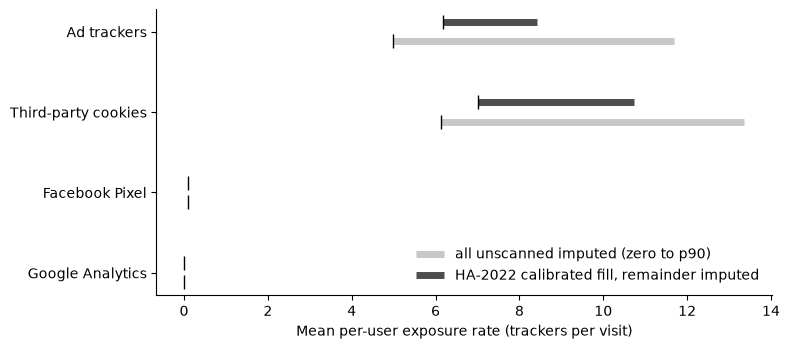

In [5]:
fig, ax = plt.subplots(figsize=(8, 3.6))
y = np.arange(len(bounds))
ax.hlines(y + 0.12, bounds["zero"], bounds["p90"], color="#c7c7c7", lw=5,
          label="all unscanned imputed (zero to p90)")
ax.hlines(y - 0.12, bounds["ha_zero"], bounds["ha_p90"], color="#4d4d4d", lw=5,
          label="HA-2022 calibrated fill, remainder imputed")
ax.plot(bounds["zero"], y + 0.12, "|", color="#000000", ms=10)
ax.plot(bounds["ha_zero"], y - 0.12, "|", color="#000000", ms=10)
ax.set_yticks(y)
ax.set_yticklabels(bounds["measure"])
ax.set_xlabel("Mean per-user exposure rate (trackers per visit)")
ax.spines[["top", "right"]].set_visible(False)
ax.invert_yaxis()
ax.legend(frameon=False, loc="lower right")
plt.tight_layout()
save_mpl_fig(os.path.join(config.FIGURES_DIR, "coverage_bounds"))
plt.show()

## Reading the results

The `zero`-to-`p90` spread is how far the missing-domain problem could move
each estimate under assumption alone; the `ha_zero`-to-`ha_p90` spread is what
remains once ~63% of the unscanned visit mass takes a calibrated, measured
value instead of an assumption. The `calib_*` columns report the calibration
itself (expected Blacklight count when HTTP Archive does / does not see the
measure on a domain). Where the published (`zero`) value sits inside the
tightened interval — and how wide that interval is relative to the estimate —
is the answer to the coverage question, in either direction.